In [38]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target'] = 0

# FIX: use concat instead of append
df = pd.concat([df, df1], ignore_index=True)

# FIX: shuffle and reset index
df = df.sample(40).reset_index(drop=True)


In [45]:
df.head()
     
     

,feature1,feature2,feature3,target
0,-0.367548,-1.137460,-1.322148,1
1,0.177061,-0.598109,1.226512,0
2,0.420623,0.411620,-0.071324,1
3,1.968435,-0.547788,-0.679418,1
4,-2.506230,0.146960,0.606195,1


In [46]:

import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()
     

In [47]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
     


In [48]:

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [60]:
#step-3 - Eigen values and Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

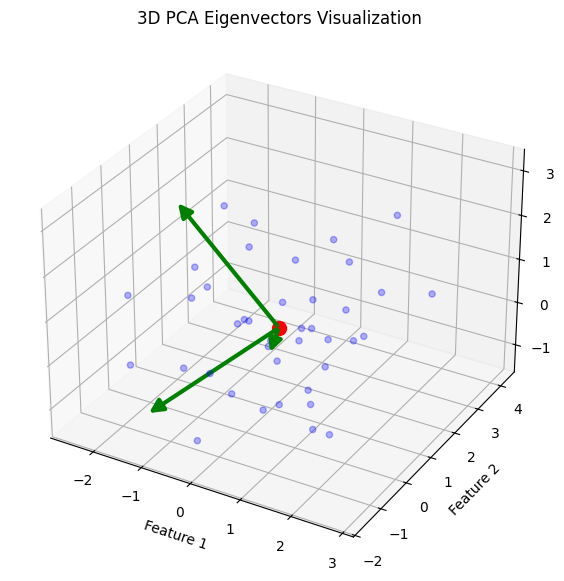

In [56]:
# %pylab inline  # optional in Jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

# -----------------------------
# Step 3: Arrow3D (FIXED CLASS)
# -----------------------------
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs, ys, zs = proj3d.proj_transform(
            self._verts3d[0],
            self._verts3d[1],
            self._verts3d[2],
            self.axes.M
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    # REQUIRED FIX for Matplotlib
    def do_3d_projection(self, renderer=None):
        xs, ys, zs = proj3d.proj_transform(
            self._verts3d[0],
            self._verts3d[1],
            self._verts3d[2],
            self.axes.M
        )
        return np.min(zs)

# -----------------------------
# Step 4: Plot
# -----------------------------
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Data points
ax.scatter(df['feature1'], df['feature2'], df['feature3'],
           color='blue', alpha=0.3)

# Mean point
ax.scatter(mean[0], mean[1], mean[2],
           color='red', s=100)

# Eigenvectors (PCA directions)
for v in eigen_vectors.T:
    v = v * 3  # scale for visibility
    arrow = Arrow3D(
        [mean[0], mean[0] + v[0]],
        [mean[1], mean[1] + v[1]],
        [mean[2], mean[2] + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="green"
    )
    ax.add_artist(arrow)

# Labels
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.title('3D PCA Eigenvectors Visualization')
plt.show()

In [58]:
# Step 1: Extract features
X = df[['feature1','feature2','feature3']].values

# Step 2: Center data (VERY IMPORTANT)
X_centered = X - np.mean(X, axis=0)

# Step 3: Select top 2 principal components
pc = eigen_vectors[:, :2]

# Step 4: Transform data
transformed_df = np.dot(X_centered, pc)

# Step 5: Create DataFrame
new_df = pd.DataFrame(transformed_df, columns=['PC1','PC2'])
new_df['target'] = df['target'].values

new_df.head()

,PC1,PC2,target
0,2.505764,-0.892313,1
1,0.404028,0.573295,0
2,0.463190,-0.524456,1
3,0.389620,-2.041777,1
4,1.998517,1.988996,1


In [ ]:
import plotly.express as px

# Convert target to string (for categorical coloring)
new_df['target'] = new_df['target'].astype(str)

# Create scatter plot
fig = px.scatter(
    data_frame=new_df,
    x='PC1',
    y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.G10,
    title='PCA Projection (2D Visualization)'
)

# Improve marker styling
fig.update_traces(
    marker=dict(
        size=10,
        line=dict(width=1.5, color='black')
    )
)

# Improve layout
fig.update_layout(
    xaxis_title='Principal Component 1',
    yaxis_title='Principal Component 2',
    legend_title='Class',
    template='plotly_dark'
)

fig.show()